# 01_EDA_Diabetes: Exploratory Data Analysis of Pima Indians Diabetes Dataset

The analysis includes:
- Dataset overview
- Missing value analysis
- Duplicate value analysis
- Class distribution
- Feature distributions
- Outlier analysis
- Correlation analysis
- Feature vs Target analysis
- Skewness analysis
- Zero value analysis
- Key insights

Part1

In [46]:
# Step 1 : Import Required Libraries
# Pandas is used for loading and manipulating tabular data.
import pandas as pd

# NumPy is used for numerical computations.
import numpy as np

# Matplotlib is the basic plotting library in Python.
import matplotlib.pyplot as plt

# Seaborn is used to create attractive statistical visualizations.
import seaborn as sns

# Set a professional plotting style
sns.set_style("whitegrid")

# Set default figure size for all plots
plt.rcParams["figure.figsize"] = (8, 5)

In [47]:
df = pd.read_csv("/content/diabetes (3).csv")

In [48]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [49]:
print("Rows and Columns :", df.shape)

Rows and Columns : (768, 9)


In [50]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [51]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Part2

In [53]:
# Count missing (NaN) values in each column
missing_values = df.isnull().sum()

print("Missing Values in Each Column:\n")
display(missing_values)

# Calculate total missing values
total_missing = missing_values.sum()

print(f"\nTotal Missing Values in Dataset: {total_missing}")

Missing Values in Each Column:



,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0



Total Missing Values in Dataset: 0


In [54]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of Duplicate Rows: {duplicate_count}")

# Remove duplicate rows if any exist
if duplicate_count > 0:
    df = df.drop_duplicates()

    print("\nDuplicate rows removed successfully.")

else:
    print("\nNo duplicate rows found.")

Number of Duplicate Rows: 0

No duplicate rows found.


In [55]:
# Step 7 : Verify Dataset Size

print("Updated Dataset Shape")

print(df.shape)

Updated Dataset Shape
(768, 9)


In [56]:
# ==========================================================
# Step 8 : Count Medically Impossible Zero Values
# ==========================================================

# Features where zero is medically invalid
zero_columns = [

    "Glucose",

    "BloodPressure",

    "SkinThickness",

    "Insulin",

    "BMI"

]

print("Number of Zero Values\n")

for column in zero_columns:

    zero_count = (df[column] == 0).sum()

    print(f"{column}: {zero_count}")

Number of Zero Values

Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11


In [57]:

# ==========================================================
# Step 9 : Zero Value Summary Table
# ==========================================================

zero_summary = []

for column in zero_columns:

    zero_summary.append({

        "Feature": column,

        "Zero Values": (df[column] == 0).sum()

    })

zero_df = pd.DataFrame(zero_summary)

display(zero_df)

,Feature,Zero Values
0,Glucose,5
1,BloodPressure,35
2,SkinThickness,227
3,Insulin,374
4,BMI,11


In [58]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


part3

In [59]:
# ==========================================================
# Step 11 : Class Distribution
# ==========================================================

print("Outcome Value Counts:\n")

display(df["Outcome"].value_counts())

print("\nPercentage Distribution:\n")

display((df["Outcome"].value_counts(normalize=True) * 100).round(2))

Outcome Value Counts:



,count
Outcome,
0,500
1,268



Percentage Distribution:



,proportion
Outcome,
0,65.1
1,34.9


/tmp/ipykernel_3685/2540892417.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


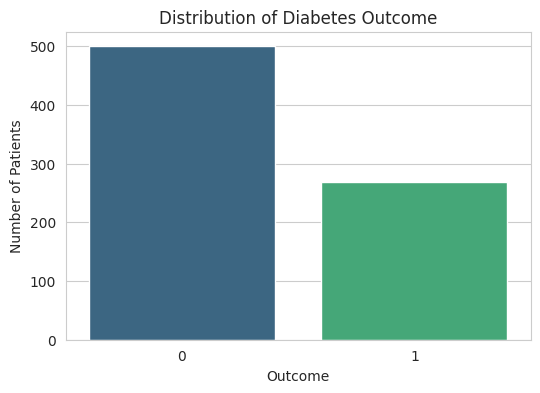

In [60]:
# ==========================================================
# Step 12 : Count Plot
# ==========================================================

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Outcome",
    palette="viridis"
)

plt.title("Distribution of Diabetes Outcome")

plt.xlabel("Outcome")

plt.ylabel("Number of Patients")

plt.show()

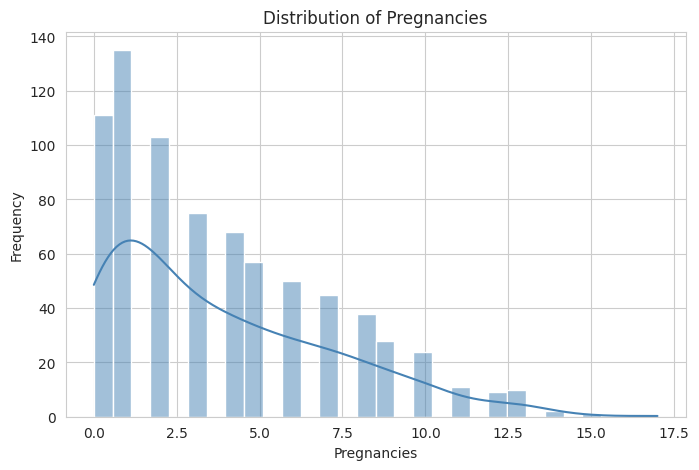

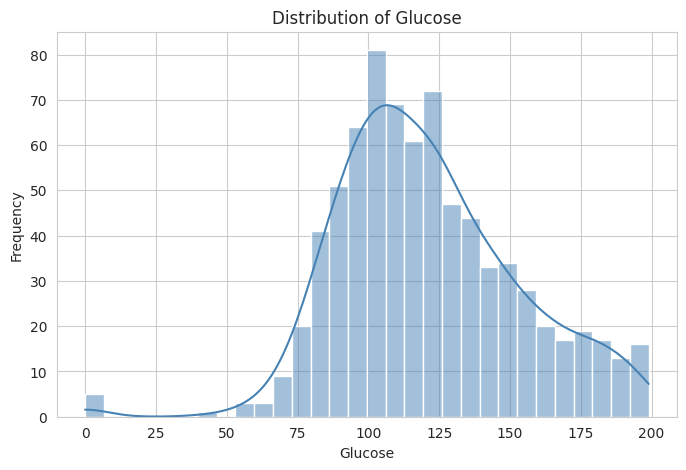

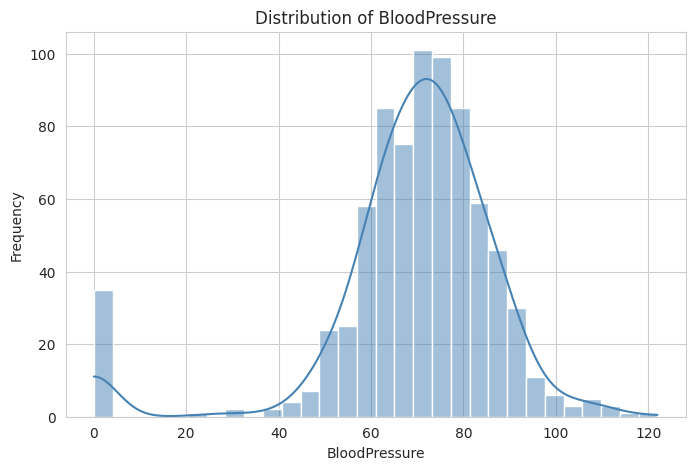

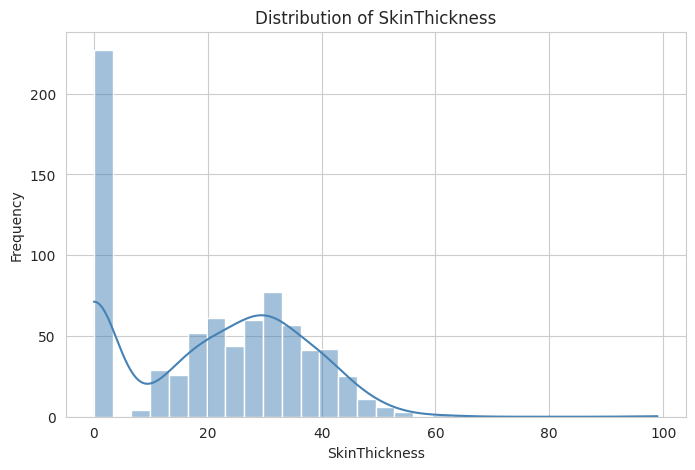

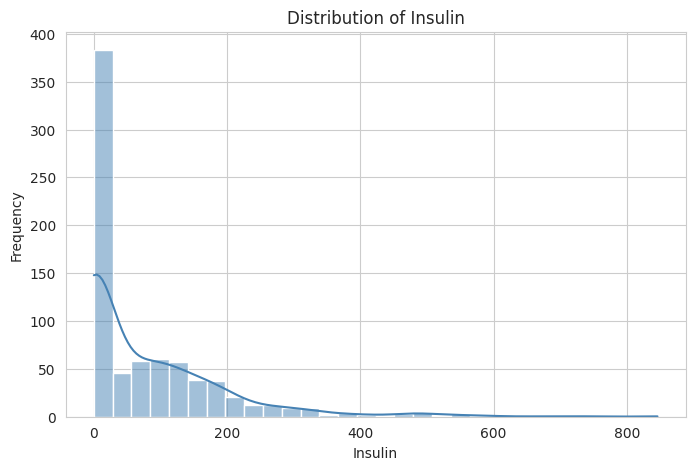

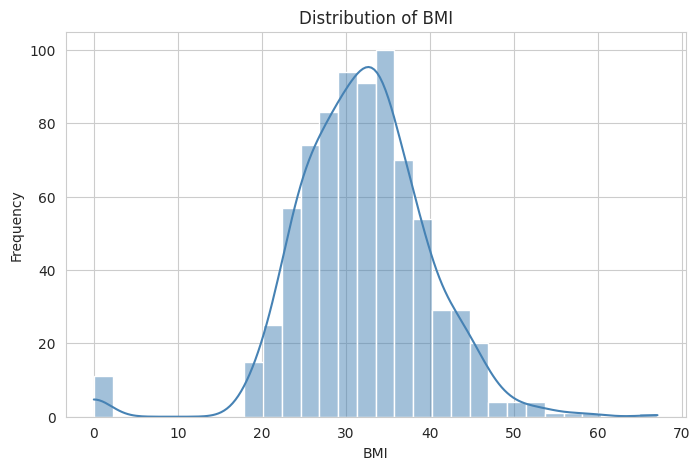

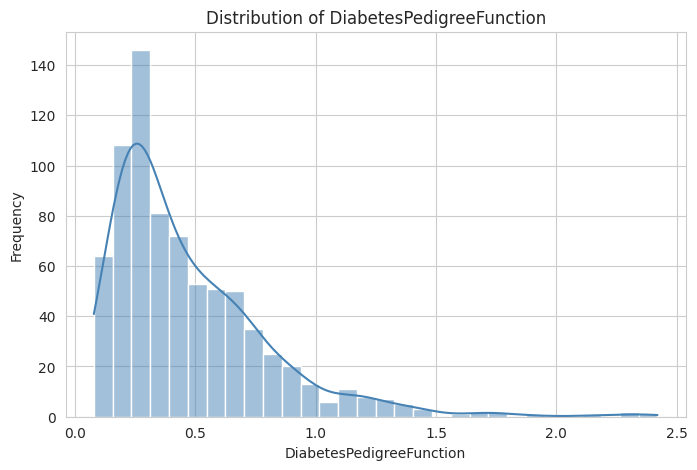

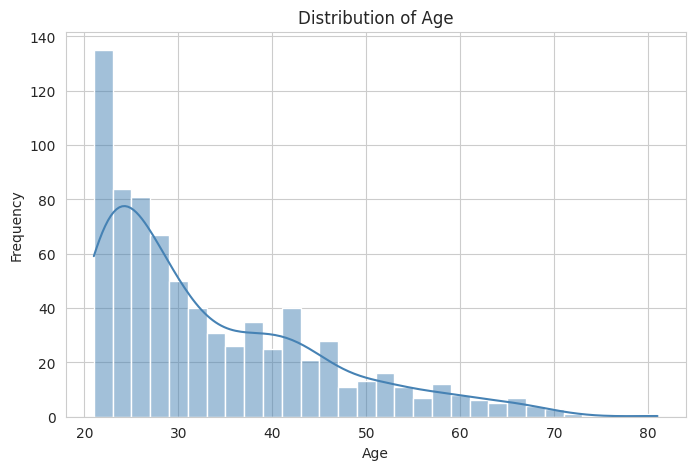

In [61]:
# ==========================================================
# Step 13 : Histograms
# ==========================================================

numerical_features = [

    "Pregnancies",

    "Glucose",

    "BloodPressure",

    "SkinThickness",

    "Insulin",

    "BMI",

    "DiabetesPedigreeFunction",

    "Age"

]

for feature in numerical_features:

    plt.figure(figsize=(8,5))

    sns.histplot(

        df[feature],

        kde=True,

        bins=30,

        color="steelblue"

    )

    plt.title(f"Distribution of {feature}")

    plt.xlabel(feature)

    plt.ylabel("Frequency")

    plt.show()

In [62]:
# ==========================================================
# Step 14 : Interpretation
# ==========================================================

for feature in numerical_features:

    skew = df[feature].skew()

    print("="*60)

    print(feature)

    print("="*60)

    if skew > 0.5:

        print("Positively Skewed")

    elif skew < -0.5:

        print("Negatively Skewed")

    else:

        print("Approximately Symmetrical")

    print(f"Skewness = {round(skew,2)}\n")

Pregnancies
Positively Skewed
Skewness = 0.9

Glucose
Approximately Symmetrical
Skewness = 0.17

BloodPressure
Negatively Skewed
Skewness = -1.84

SkinThickness
Approximately Symmetrical
Skewness = 0.11

Insulin
Positively Skewed
Skewness = 2.27

BMI
Approximately Symmetrical
Skewness = -0.43

DiabetesPedigreeFunction
Positively Skewed
Skewness = 1.92

Age
Positively Skewed
Skewness = 1.13



In [63]:
# ==========================================================
# Step 15 : Statistical Summary
# ==========================================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


part4

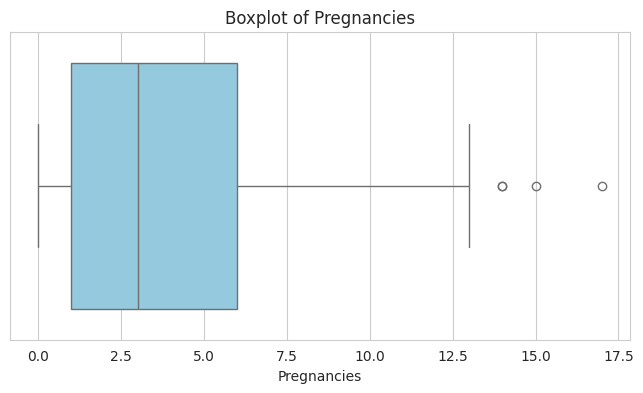

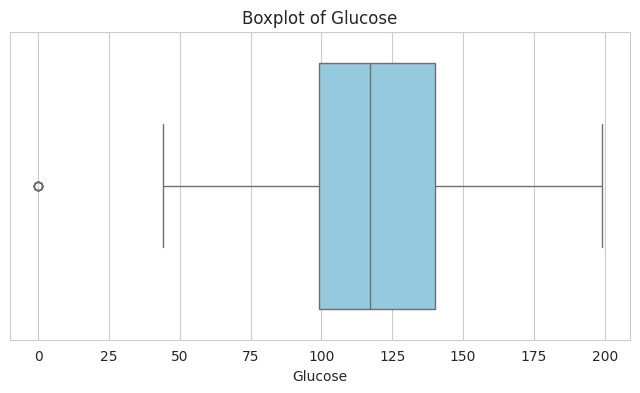

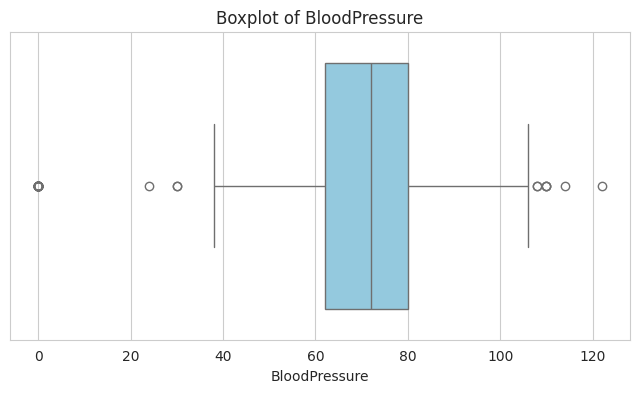

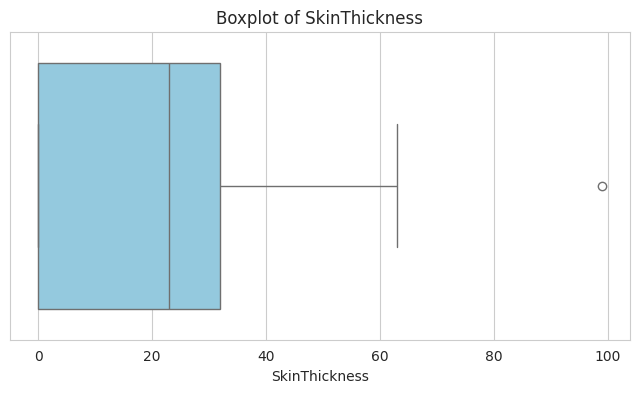

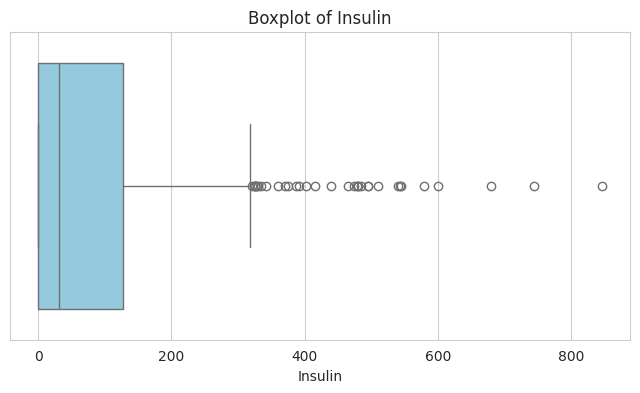

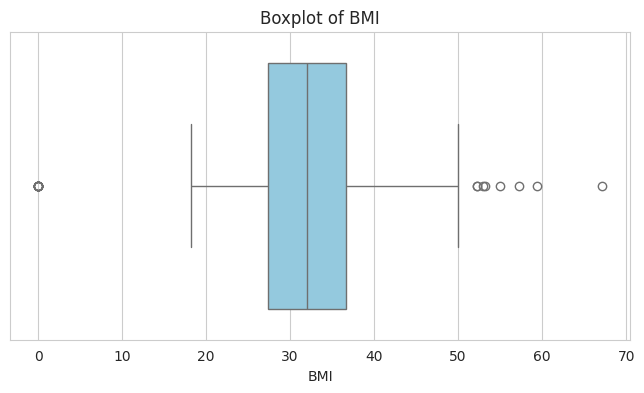

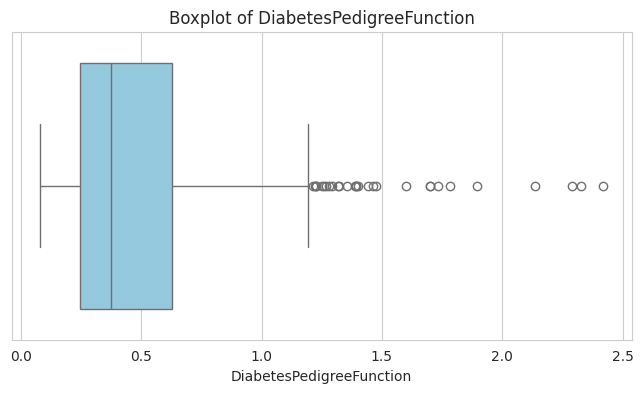

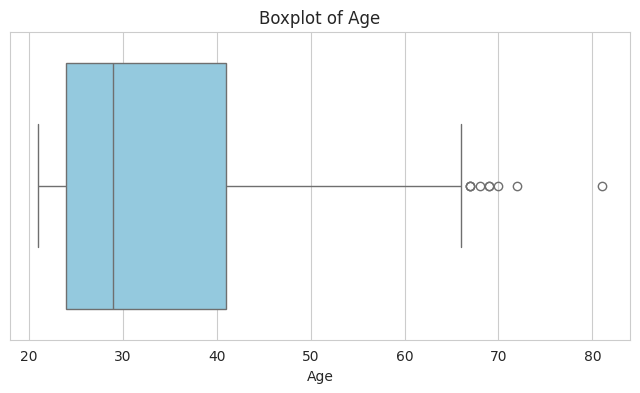

In [64]:
# ==========================================================
# Step 17 : Boxplots
# ==========================================================

numerical_features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

for feature in numerical_features:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[feature],
        color="skyblue"
    )

    plt.title(f"Boxplot of {feature}")

    plt.xlabel(feature)

    plt.show()

In [65]:
# ==========================================================
# Step 18 : Outlier Detection (IQR Method)
# ==========================================================

outlier_summary = []

for feature in numerical_features:

    Q1 = df[feature].quantile(0.25)

    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower) |
        (df[feature] > upper)
    ].shape[0]

    outlier_summary.append({

        "Feature": feature,

        "Q1": round(Q1,2),

        "Q3": round(Q3,2),

        "IQR": round(IQR,2),

        "Lower Bound": round(lower,2),

        "Upper Bound": round(upper,2),

        "Outliers": outliers

    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers
0,Pregnancies,1.00,6.00,5.00,-6.50,13.50,4
1,Glucose,99.00,140.25,41.25,37.12,202.12,5
2,BloodPressure,62.00,80.00,18.00,35.00,107.00,45
3,SkinThickness,0.00,32.00,32.00,-48.00,80.00,1
4,Insulin,0.00,127.25,127.25,-190.88,318.12,34
5,BMI,27.30,36.60,9.30,13.35,50.55,19
6,DiabetesPedigreeFunction,0.24,0.63,0.38,-0.33,1.20,29
7,Age,24.00,41.00,17.00,-1.50,66.50,9


In [66]:
# ==========================================================
# Step 19 : Correlation Matrix
# ==========================================================

correlation_matrix = df.corr(numeric_only=True)

display(correlation_matrix)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


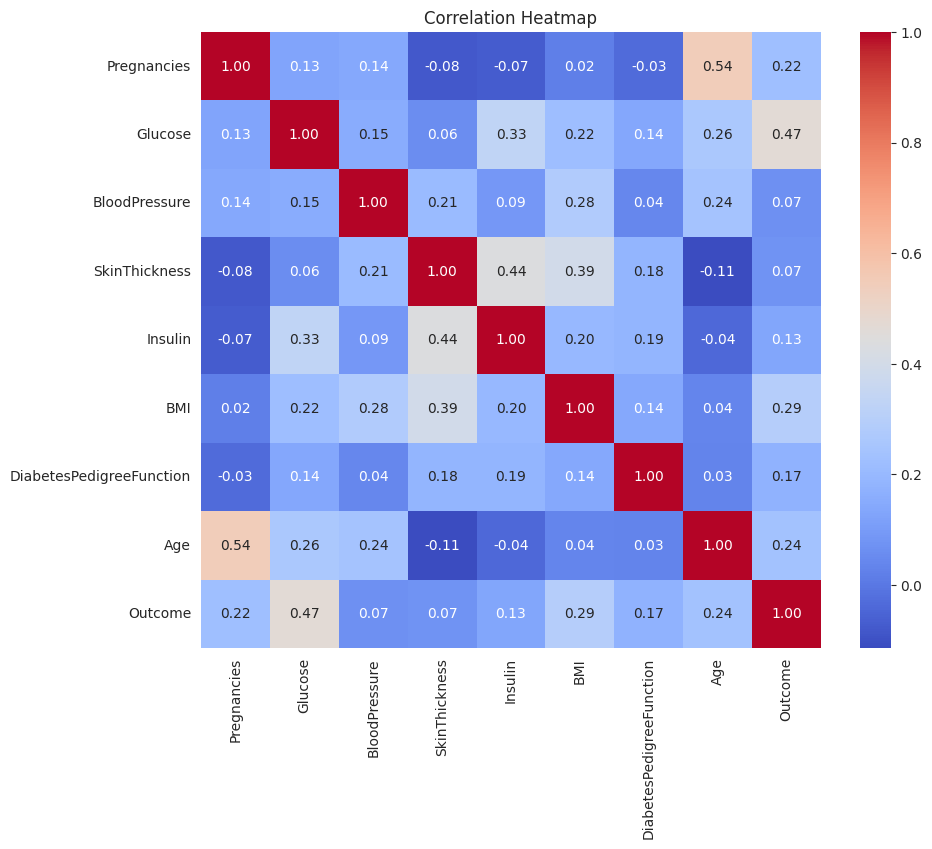

In [67]:
# ==========================================================
# Step 19 : Correlation Heatmap
# ==========================================================

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

/tmp/ipykernel_3685/3643356562.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


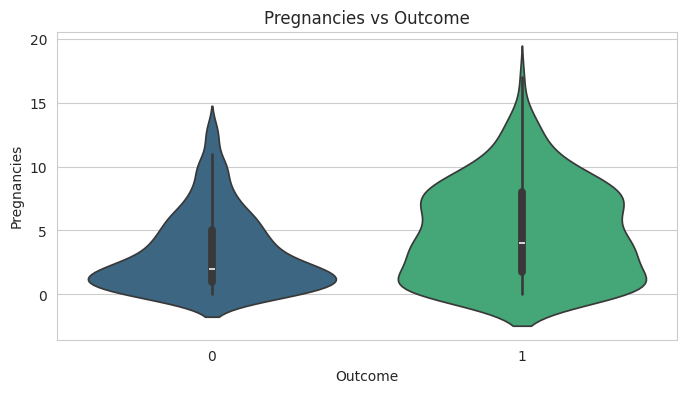

/tmp/ipykernel_3685/3643356562.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


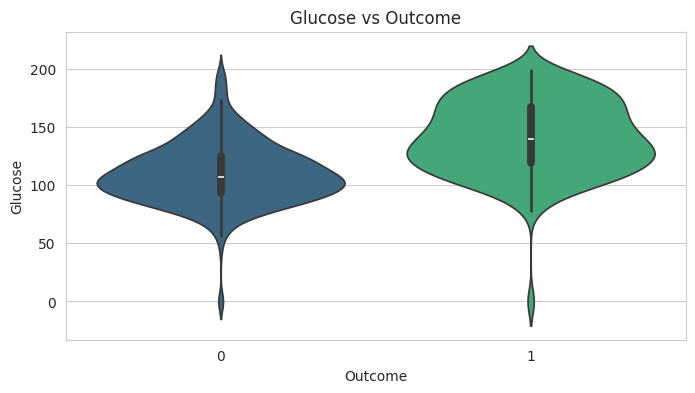

/tmp/ipykernel_3685/3643356562.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


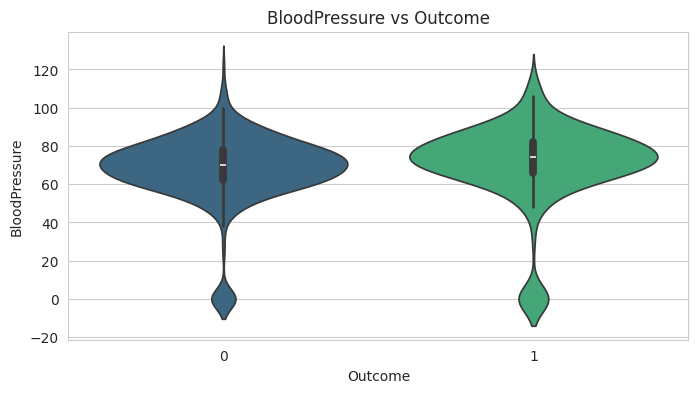

/tmp/ipykernel_3685/3643356562.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


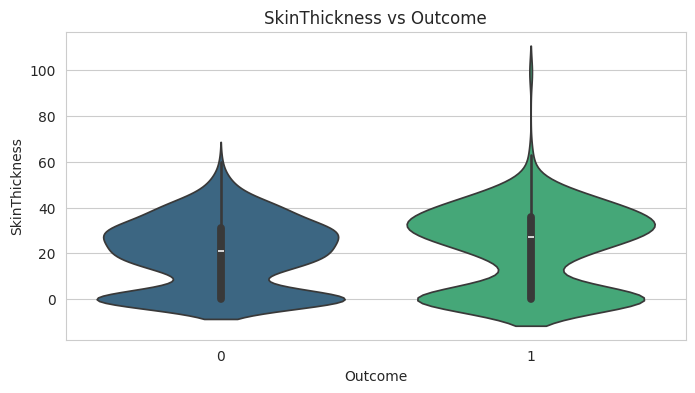

/tmp/ipykernel_3685/3643356562.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


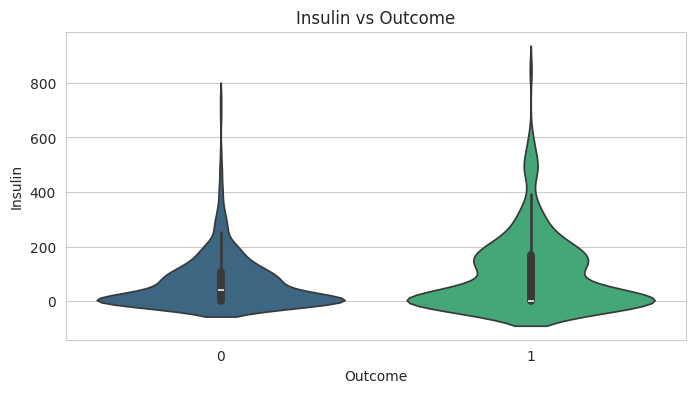

/tmp/ipykernel_3685/3643356562.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


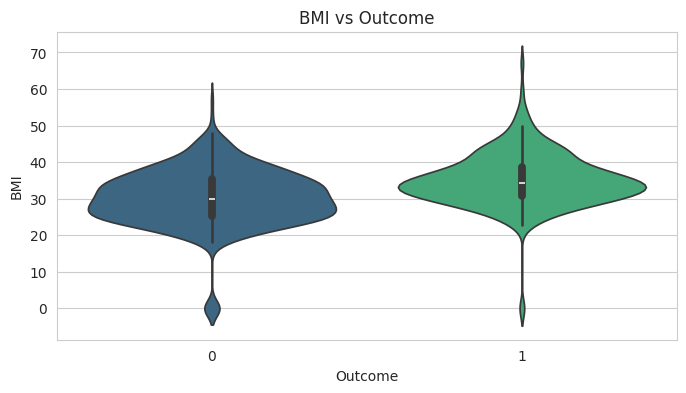

/tmp/ipykernel_3685/3643356562.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


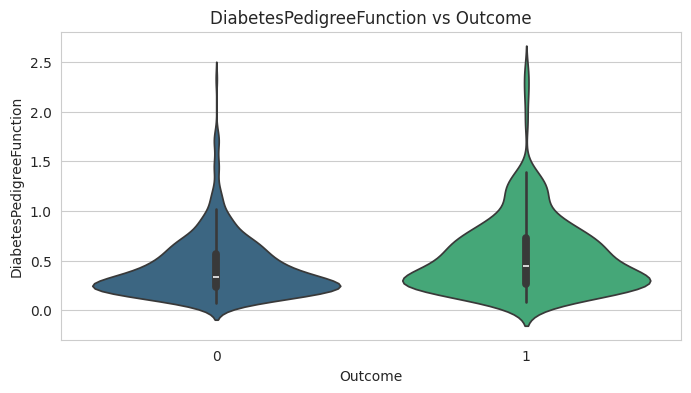

/tmp/ipykernel_3685/3643356562.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


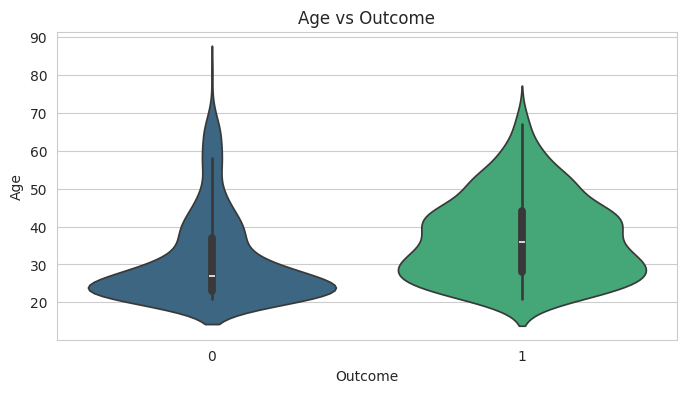

In [68]:
# ==========================================================
# Step 20 : Violin Plots
# ==========================================================

for feature in numerical_features:

    plt.figure(figsize=(8,4))

    sns.violinplot(

        x="Outcome",

        y=feature,

        data=df,

        palette="viridis"

    )

    plt.title(f"{feature} vs Outcome")

    plt.show()

part5

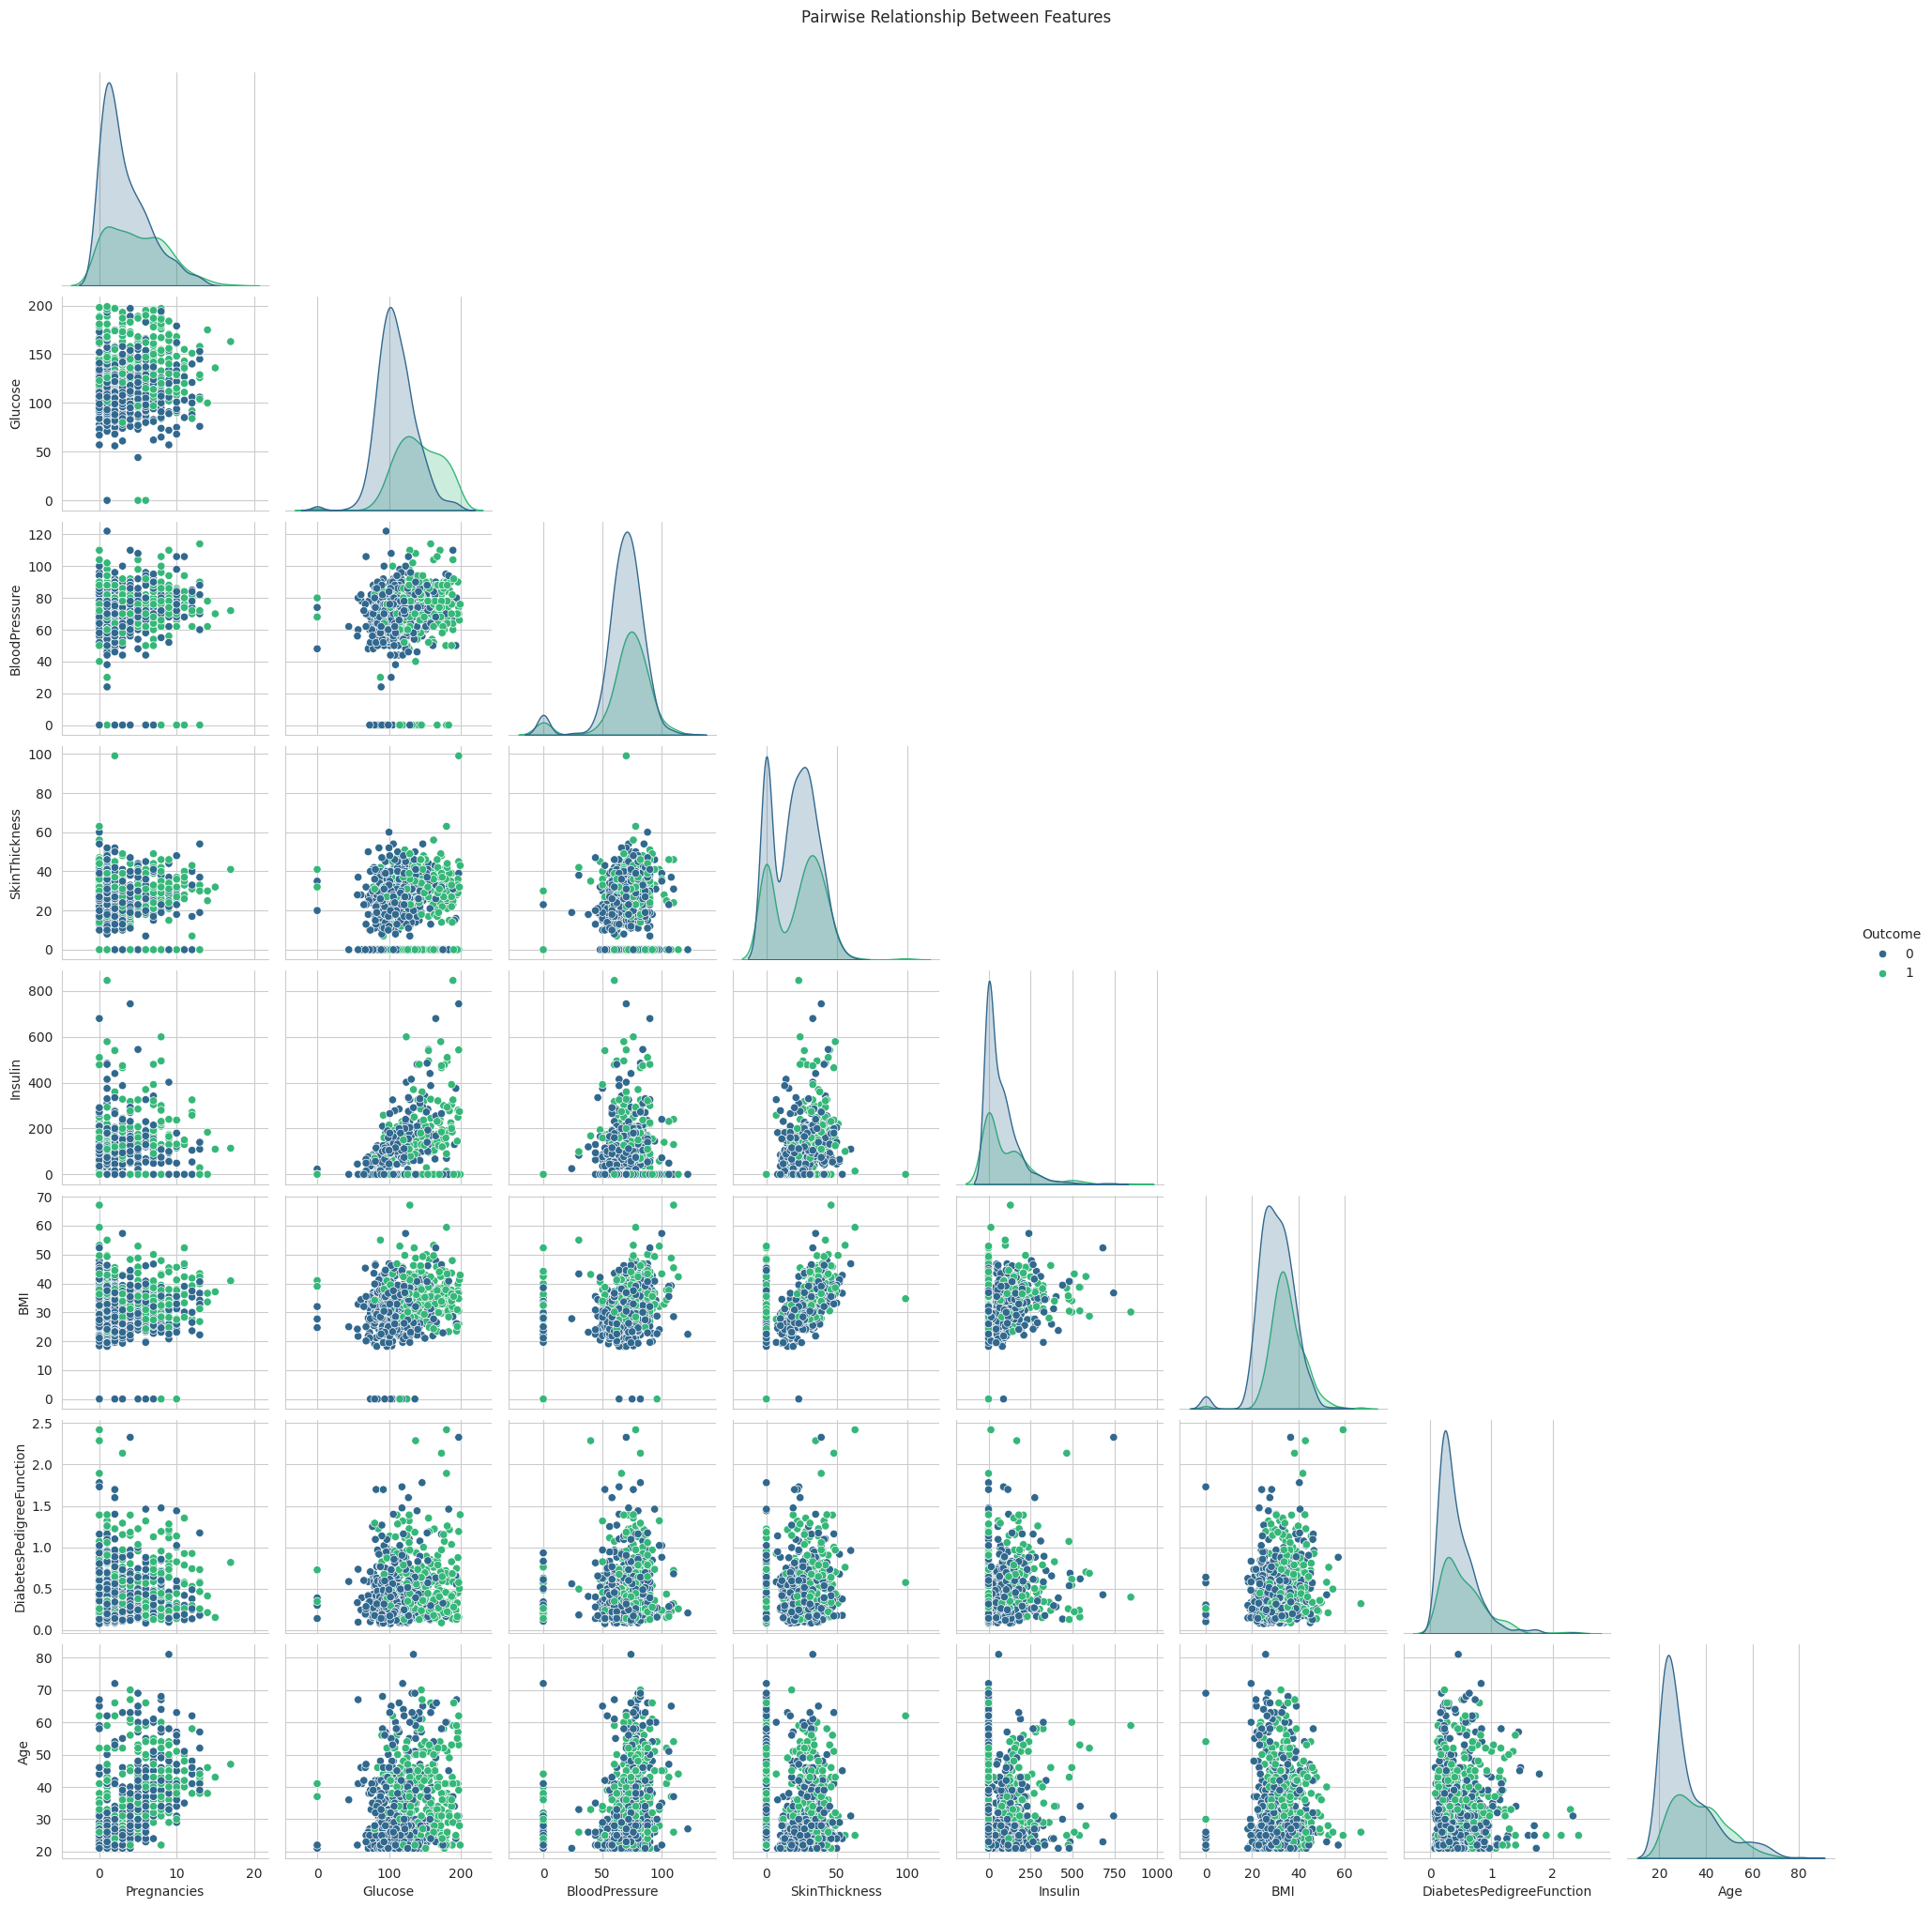

In [69]:
# ==========================================================
# Step 21 : Pair Plot
# ==========================================================

sns.pairplot(
    df,
    hue="Outcome",
    diag_kind="kde",
    corner=True,
    palette="viridis"
)

plt.suptitle(
    "Pairwise Relationship Between Features",
    y=1.02
)

plt.show()

In [70]:
# ==========================================================
# Step 22 : Skewness
# ==========================================================

skewness = df[numerical_features].skew()

display(skewness.to_frame("Skewness"))

,Skewness
Pregnancies,0.901674
Glucose,0.173754
BloodPressure,-1.843608
SkinThickness,0.109372
Insulin,2.272251
BMI,-0.428982
DiabetesPedigreeFunction,1.919911
Age,1.129597


In [71]:
# ==========================================================
# Step 22 : Interpretation
# ==========================================================

for feature in numerical_features:

    value = df[feature].skew()

    if value > 0.5:

        print(f"{feature}: Positively Skewed ({value:.2f})")

    elif value < -0.5:

        print(f"{feature}: Negatively Skewed ({value:.2f})")

    else:

        print(f"{feature}: Approximately Symmetric ({value:.2f})")

Pregnancies: Positively Skewed (0.90)
Glucose: Approximately Symmetric (0.17)
BloodPressure: Negatively Skewed (-1.84)
SkinThickness: Approximately Symmetric (0.11)
Insulin: Positively Skewed (2.27)
BMI: Approximately Symmetric (-0.43)
DiabetesPedigreeFunction: Positively Skewed (1.92)
Age: Positively Skewed (1.13)


| Feature                  | Description                            | Unit  |
| ------------------------ | -------------------------------------- | ----- |
| Pregnancies              | Number of pregnancies                  | Count |
| Glucose                  | Plasma glucose concentration           | mg/dL |
| BloodPressure            | Diastolic blood pressure               | mm Hg |
| SkinThickness            | Triceps skin fold thickness            | mm    |
| Insulin                  | 2-Hour serum insulin                   | μU/mL |
| BMI                      | Body Mass Index                        | kg/m² |
| DiabetesPedigreeFunction | Diabetes pedigree score                | Score |
| Age                      | Age of patient                         | Years |
| Outcome                  | Target (0 = No Diabetes, 1 = Diabetes) | Class |
